## Building a Knowledge Graph for Chronic Disease Risk Analysis

**Student:** Andrea Pradas (I6439726)

**Course:** Building and Mining Knowledge Graphs

**Instructors:**  Michel Dumontier, Maryam Mohammadi, Shervin Mehryar & Rishabh Jakhar

**Date:** March 2026



In [348]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [307]:
# IMPORT LIBRARIES + INSTALL DEPENDENCIES
import sys
!{sys.executable} -m pip install --upgrade pip

# Uninstall potentially incompatible versions to force correct installations
!{sys.executable} -m pip uninstall -y spacy thinc

# Install required versions
!{sys.executable} -m pip install \
    "rdflib" \
    "graphviz" \
    "sparqlwrapper" \
    "python-dotenv" \
    "pydantic==1.10.26" \
    "thinc==8.2.3" \
    "spacy==3.7.4" \
    "spacy-llm==0.7.3" \
    "openai==0.28.1" \
    "scispacy==0.6.2"
#!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz
!{sys.executable} -m pip check


# Files
import pandas as pd
import numpy as np
import seaborn as sns

# Graphs
import networkx as nx
import matplotlib.pyplot as plt
from rdflib import URIRef, BNode, Literal, Namespace, Graph
from rdflib.namespace import FOAF, DCTERMS, XSD, RDF, SDO, RDFS

# NLP and LLMs
"""import json
import spacy
import spacy_llm
from spacy.util import load_config_from_str
from scispacy.linking import EntityLinker
import re
from dotenv import load_dotenv, set_key"""

# Visualization
import pydotplus
from IPython.display import Image, display
from rdflib.tools.rdf2dot import rdf2dot
import io
import random
import rdflib
import networkx as nx
import matplotlib.pyplot as plt
from rdflib.extras.external_graph_libs import rdflib_to_networkx_digraph
from rdflib.extras.external_graph_libs import rdflib_to_networkx_multidigraph

# Queries
from rdflib.plugins.sparql import prepareQuery
from rdflib.tools.rdf2dot import rdf2dot
from IPython.display import display, HTML
from pygments import highlight
from pygments.lexers import SparqlLexer
from pygments.formatters import HtmlFormatter


Found existing installation: spacy 3.7.4
Uninstalling spacy-3.7.4:
  Successfully uninstalled spacy-3.7.4
Found existing installation: thinc 8.2.3
Uninstalling thinc-8.2.3:
  Successfully uninstalled thinc-8.2.3
  Using cached thinc-8.2.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (15 kB)
  Using cached spacy-3.7.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (27 kB)
Using cached thinc-8.2.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (865 kB)
Using cached spacy-3.7.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (6.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [spacy]
ipython 7.34.0 requires jedi, which is not installed.
jax 0.7.2 has requirement numpy>=2.0, but you have numpy 1.26.4.
langchain-core 1.2.16 has requirement pydantic<3.0.0,>=2.7.4, but you have pydantic 1.10.26.
langchain 1.2.10 has requirement pydantic<3.0.0,>=2.7.4, but you have pydantic 1.10.26.
xarray-einstats 0.10.0 has requirement n

## 1. Introduction

Knowledge Graphs (KGs) provide a structured and machine-interpretable way of representing data.
Instead of storing information only in tabular form, KGs represent entities and their relationships
using triples of the form: (subject, predicate, object)

This project aims to construct a Knowledge Graph (KG) from health survey data in order to model relationships between patients, chronic diseases and risk factors.

## 2. Dataset Description

The dataset used in this project is the *Health Dataset (Diabetes, Hypertension and Stroke Prediction)* published by Chuks, P. (2024) on Kaggle. Available at: https://www.kaggle.com/datasets/prosperchuks/health-dataset

The dataset contains **70,692 survey responses** with health indicators related to chronic diseases and lifestyle risk factors. It includes variables such as:

- High blood pressure
- Body Mass Index (BMI)
- General health
- Mental health
- Physical health
- Age
- Diabetes diagnosis

Each row in the dataset represents a survey response from an individual patient. The goal is to convert these tabular records into RDF triples to build a Knowledge Graph.

## 3. Dataset Exploration

In [308]:
df_diabetes = pd.read_csv("/content/drive/MyDrive/Project_AndreaPradas/Data/diabetes_data.csv",  nrows=10000)
binary_cols = [
    "HighChol", "CholCheck", "Smoker", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
    "DiffWalk", "Stroke", "HighBP", "Diabetes"
]
df_diabetes[binary_cols] = df_diabetes[binary_cols].astype(int)
categorical_cols = ["Sex", "GenHlth"]
df_diabetes[categorical_cols] = df_diabetes[categorical_cols].astype(int)
df_diabetes["Age"] = df_diabetes["Age"].astype(int)
df_diabetes["BMI"] = df_diabetes["BMI"].astype("float")
df_diabetes["MentHlth"] = df_diabetes["MentHlth"].astype(int)
df_diabetes["PhysHlth"] = df_diabetes["PhysHlth"].astype(int)
print(df_diabetes.head(10))
df_diabetes.info()

   Age  Sex  HighChol  CholCheck   BMI  Smoker  HeartDiseaseorAttack  \
0    4    1         0          1  26.0       0                     0   
1   12    1         1          1  26.0       1                     0   
2   13    1         0          1  26.0       0                     0   
3   11    1         1          1  28.0       1                     0   
4    8    0         0          1  29.0       1                     0   
5    1    0         0          1  18.0       0                     0   
6   13    1         1          1  26.0       1                     0   
7    6    1         0          1  31.0       1                     0   
8    3    0         0          1  32.0       0                     0   
9    6    1         0          1  27.0       1                     0   

   PhysActivity  Fruits  Veggies  HvyAlcoholConsump  GenHlth  MentHlth  \
0             1       0        1                  0        3         5   
1             0       1        0                  0        

In [309]:
df_hypertension = pd.read_csv("/content/drive/MyDrive/Project_AndreaPradas/Data/hypertension_data.csv", nrows=10000)
int_cols = [
    "age","cp","trestbps","chol","fbs",
    "restecg","thalach","exang","slope","ca","thal","target"
]

df_hypertension[int_cols] = df_hypertension[int_cols].astype(int)
df_hypertension["oldpeak"] = df_hypertension["oldpeak"].astype("float")
df_hypertension.info()
df_hypertension.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       10000 non-null  int64  
 1   sex       9990 non-null   float64
 2   cp        10000 non-null  int64  
 3   trestbps  10000 non-null  int64  
 4   chol      10000 non-null  int64  
 5   fbs       10000 non-null  int64  
 6   restecg   10000 non-null  int64  
 7   thalach   10000 non-null  int64  
 8   exang     10000 non-null  int64  
 9   oldpeak   10000 non-null  float64
 10  slope     10000 non-null  int64  
 11  ca        10000 non-null  int64  
 12  thal      10000 non-null  int64  
 13  target    10000 non-null  int64  
dtypes: float64(2), int64(12)
memory usage: 1.1 MB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,57,1.0,3,145,233,1,0,150,0,2.3,0,0,1,1
1,64,0.0,2,130,250,0,1,187,0,3.5,0,0,2,1
2,52,1.0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,0.0,1,120,236,0,1,178,0,0.8,2,0,2,1
4,66,0.0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [310]:
df_stroke = pd.read_csv("/content/drive/MyDrive/Project_AndreaPradas/Data/stroke_data.csv", nrows=10000)
cat_cols = [
    "hypertension","heart_disease",
    "ever_married","work_type","Residence_type",
    "smoking_status","stroke"
]
df_stroke[cat_cols] = df_stroke[cat_cols].astype(int)
df_stroke["age"] = df_stroke["age"].astype(int)
df_stroke["avg_glucose_level"] = df_stroke["avg_glucose_level"].astype("float")
df_stroke["bmi"] = df_stroke["bmi"].astype("float")
df_stroke.info()
df_stroke.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sex                10000 non-null  int64  
 1   age                10000 non-null  int64  
 2   hypertension       10000 non-null  int64  
 3   heart_disease      10000 non-null  int64  
 4   ever_married       10000 non-null  int64  
 5   work_type          10000 non-null  int64  
 6   Residence_type     10000 non-null  int64  
 7   avg_glucose_level  10000 non-null  float64
 8   bmi                10000 non-null  float64
 9   smoking_status     10000 non-null  int64  
 10  stroke             10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


,sex,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,63,0,1,1,4,1,228.69,36.6,1,1
1,1,42,0,1,1,4,0,105.92,32.5,0,1
2,0,61,0,0,1,4,1,171.23,34.4,1,1
3,1,41,1,0,1,3,0,174.12,24.0,0,1
4,1,85,0,0,1,4,1,186.21,29.0,1,1


## 4. Data Cleaning




In [311]:
# Check for NaN
print("Diabetes NaNs:")
print(df_diabetes.isna().sum())
print("\nHypertension NaNs:")
print(df_hypertension.isna().sum())
print("\nStroke NaNs:")
print(df_stroke.isna().sum())

# Handling MISSING VALUES: Delete the rows
df_diabetes.dropna(inplace=True)
df_hypertension.dropna(inplace=True)
df_stroke.dropna(inplace=True)
# reset the indexes (avoid cofusion)
df_diabetes.reset_index(drop=True, inplace=True)
df_hypertension.reset_index(drop=True, inplace=True)
df_stroke.reset_index(drop=True, inplace=True)

# Change datatype
df_hypertension["sex"] = df_hypertension["sex"].astype(int)
df_stroke["sex"] = df_stroke["sex"].astype(int)
df_hypertension.info()
df_stroke.info()


Diabetes NaNs:
Age                     0
Sex                     0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Stroke                  0
HighBP                  0
Diabetes                0
dtype: int64

Hypertension NaNs:
age          0
sex         10
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
target       0
dtype: int64

Stroke NaNs:
sex                  0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke           

Missing values (NaN) may lead to incomplete triples in the KG, therefore they must be handled before further processing.
To maintain data consistency, rows containing missing values are removed. Since the amount of missing values is relatively small, deleting these rows does not significantly affect the dataset size.

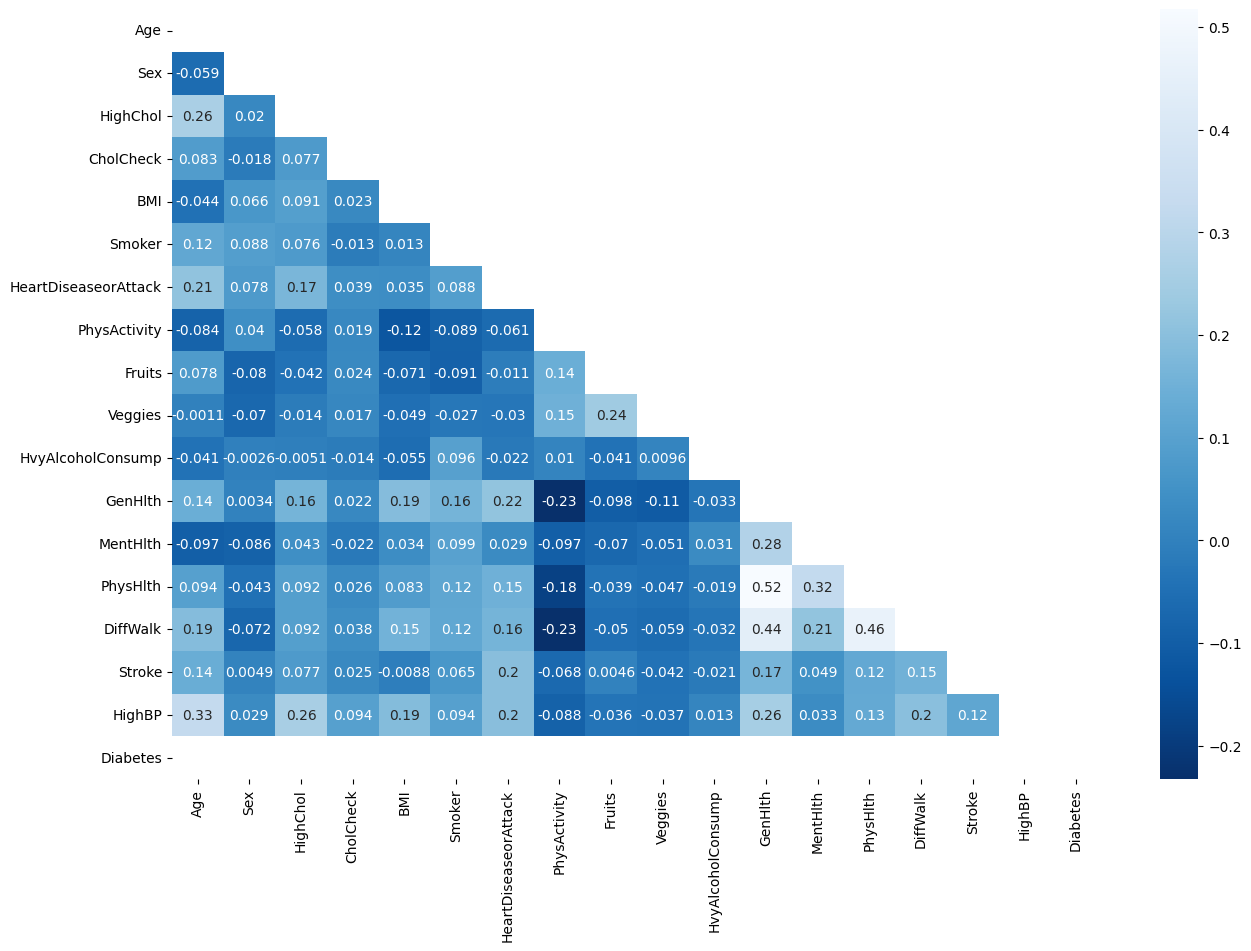

In [312]:
# Correlation matrix for DIABETES
plt.figure(figsize=(15,10))
mask=np.triu(df_diabetes.corr())
sns.heatmap(df_diabetes.corr(),mask=mask,annot=True,cmap='Blues_r')
plt.show()

In [313]:
corr_target = df_diabetes.corr()['Stroke'].sort_values(ascending=False)
print(corr_target)

Stroke                  1.000000
HeartDiseaseorAttack    0.195928
GenHlth                 0.165035
DiffWalk                0.151433
Age                     0.138774
PhysHlth                0.124692
HighBP                  0.115325
HighChol                0.076647
Smoker                  0.065389
MentHlth                0.048850
CholCheck               0.024639
Sex                     0.004907
Fruits                  0.004643
BMI                    -0.008818
HvyAlcoholConsump      -0.021243
Veggies                -0.042149
PhysActivity           -0.068219
Diabetes                     NaN
Name: Stroke, dtype: float64


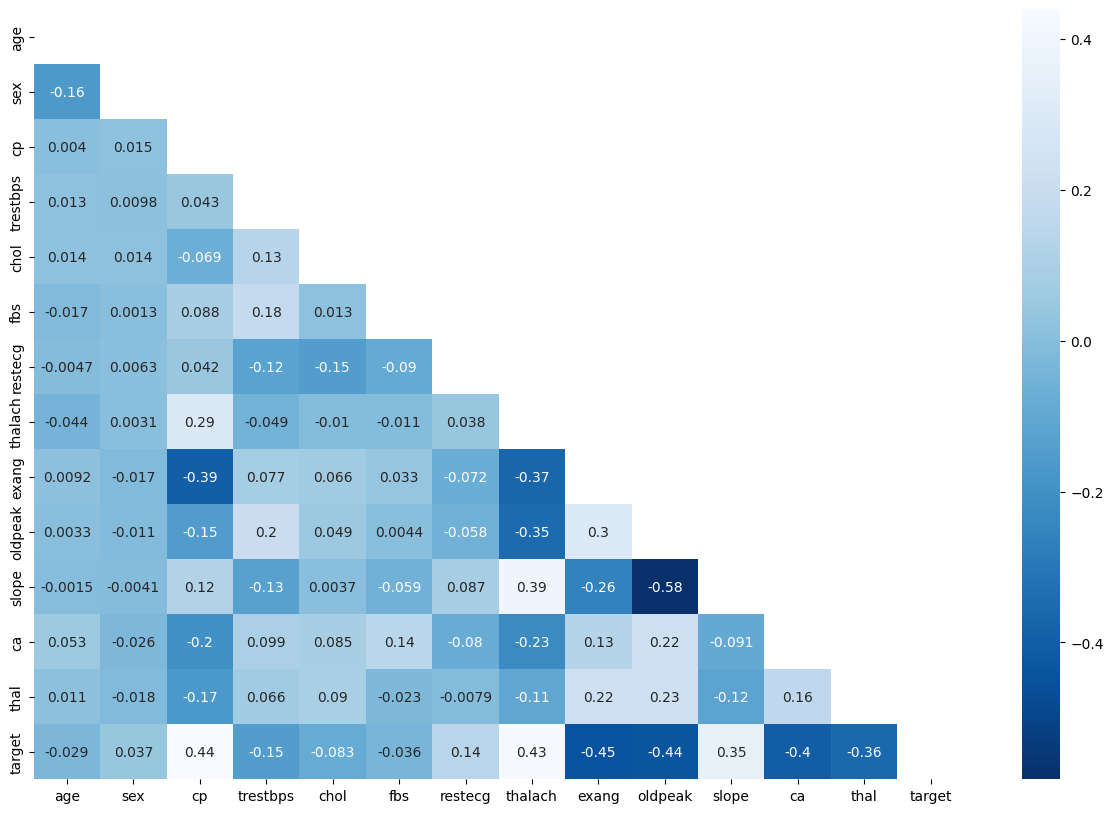

In [314]:
# Correlation matrix for HYPERTENSION
plt.figure(figsize=(15,10))
mask=np.triu(df_hypertension.corr())
sns.heatmap(df_hypertension.corr(),mask=mask,annot=True,cmap='Blues_r')
plt.show()

In [315]:
corr_target = df_hypertension.corr()['target'].sort_values(ascending=False)
print(corr_target)

target      1.000000
cp          0.439274
thalach     0.426460
slope       0.350352
restecg     0.137852
sex         0.037310
age        -0.029361
fbs        -0.036197
chol       -0.083250
trestbps   -0.149971
thal       -0.360619
ca         -0.402662
oldpeak    -0.437290
exang      -0.445863
Name: target, dtype: float64


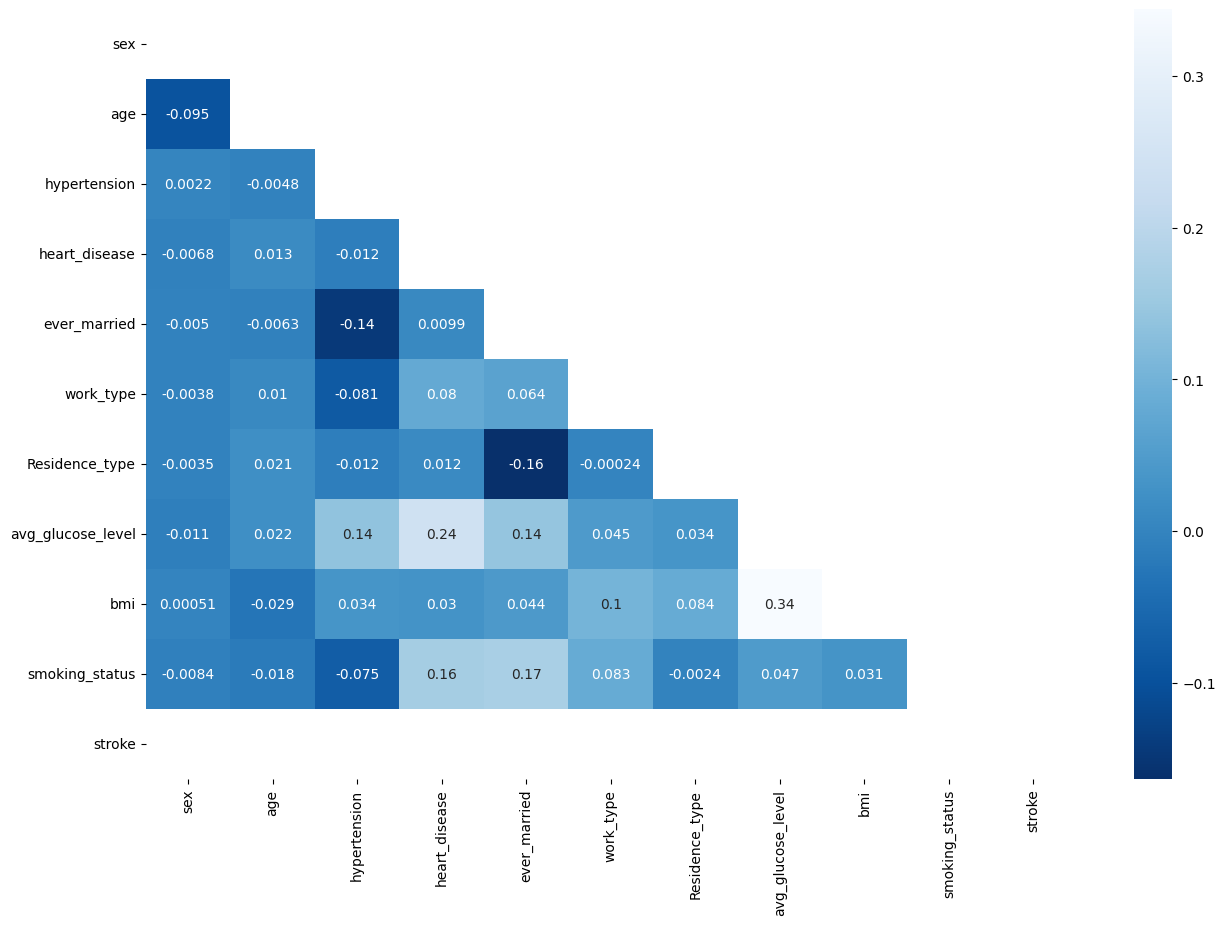

In [316]:
# Correlation matrix for STROKE
plt.figure(figsize=(15,10))
mask=np.triu(df_stroke.corr())
sns.heatmap(df_stroke.corr(),mask=mask,annot=True,cmap='Blues_r')
plt.show()

In [317]:
corr_target = df_stroke.corr()['stroke'].sort_values(ascending=False)
print(corr_target)

sex                 NaN
age                 NaN
hypertension        NaN
heart_disease       NaN
ever_married        NaN
work_type           NaN
Residence_type      NaN
avg_glucose_level   NaN
bmi                 NaN
smoking_status      NaN
stroke              NaN
Name: stroke, dtype: float64


## 6. Knowledge Graph Construction

To represent the dataset as a Knowledge Graph, RDF triples are created using the RDFLib library. In this representation, each survey response is modeled as an instance of the `Patient` class. Health indicators such as age, general health, mental health and physical health are represented as properties associated with each patient.

Additionally, chronic diseases (e.g., diabetes, hypertension, and stroke) and lifestyle risk factors (e.g., smoking or alcohol consumption) are modeled as separate entities.

In [318]:
g = Graph()

# Namespaces
SNOMED = Namespace("http://purl.bioontology.org/ontology/SNOMEDCT/")
MESH = Namespace("https://id.nlm.nih.gov/mesh/")
SDO = Namespace("http://schema.org/")
BASE = Namespace("http://kg-course.io/health/")
EX = Namespace("http://example.org/")
OWL = Namespace("http://www.w3.org/2002/07/owl#")

g.bind("snomed", SNOMED)
g.bind("mesh", MESH)
g.bind("schema", SDO)
g.bind("base", BASE)
g.bind("ex", EX)
g.bind("rdf", RDF)
g.bind("rdfs", RDFS)
g.bind("xsd", XSD)
g.bind("dcterms", DCTERMS)
g.bind("foaf", FOAF)
g.bind("owl", OWL)

### Ontology Design
Before generating the RDF triples, a simple ontology is defined to model the main entities and relationships in the dataset.
- **Patient**: represents an individual survey participant.
- **Disease**: represents chronic diseases diagnosed in patients.
- **RiskFactor**: represents behavioral or health-related factors that may contribute to disease development.


In [319]:
# Patient
g.add((BASE.Patient, RDF.type, RDFS.Class))
g.add((BASE.Patient, RDFS.label, Literal("Patient")))

# Disease
g.add((BASE.Disease, RDF.type, RDFS.Class))
g.add((BASE.Disease, RDFS.label, Literal("Disease")))

"""# RiskFactor
g.add((BASE.RiskFactor, RDF.type, RDFS.Class))
g.add((BASE.RiskFactor, RDFS.label, Literal("Risk Factor")))"""

"""# Clinical Measurement
g.add((BASE.ClinicalMeasurement, RDF.type, RDFS.Class))
g.add((BASE.ClinicalMeasurement, RDFS.label, Literal("Clinical Measurement")))
g.add((BASE.ClinicalMeasurement, RDFS.subClassOf, SDO.MedicalObservation))"""

'# Clinical Measurement\ng.add((BASE.ClinicalMeasurement, RDF.type, RDFS.Class))\ng.add((BASE.ClinicalMeasurement, RDFS.label, Literal("Clinical Measurement")))\ng.add((BASE.ClinicalMeasurement, RDFS.subClassOf, SDO.MedicalObservation))'

In [320]:
g.add((BASE.hasDisease, RDF.type, RDF.Property))
g.add((BASE.hasDisease, RDFS.domain, BASE.Patient))
g.add((BASE.hasDisease, RDFS.range, BASE.Disease))

g.add((BASE.hasRiskFactor, RDF.type, RDF.Property))
g.add((BASE.hasRiskFactor, RDFS.domain, BASE.Patient))
g.add((BASE.hasRiskFactor, RDFS.range, SDO.MedicalRiskFactor))

g.add((BASE.hasMeasurement, RDF.type, RDF.Property))
g.add((BASE.hasMeasurement, RDFS.domain, BASE.Patient))
g.add((BASE.hasMeasurement, RDFS.range, SDO.MedicalObservation))

diabetes = SNOMED["44054006"]
g.add((diabetes, RDF.type, BASE.Disease))
g.add((diabetes, RDFS.label, Literal("Diabetes Mellitus")))

hypertension = SNOMED["38341003"]
g.add((hypertension, RDF.type, BASE.Disease))
g.add((hypertension, RDFS.label, Literal("Hypertension")))

stroke = SNOMED["230690007"]
g.add((stroke, RDF.type, BASE.Disease))
g.add((stroke, RDFS.label, Literal("Stroke")))

risk_factors = {
    "smoking": {"label": "Smoking", "sameAs": SNOMED["77176002"]},
    "high_cholesterol": {"label": "High Cholesterol", "sameAs": None},
    "high_blood_pressure": {"label": "High Blood Pressure", "sameAs": SNOMED["38341003"]},
    "heart_disease": {"label": "Heart Disease", "sameAs": None},
    "difficulty_walking": {"label": "Difficulty Walking", "sameAs": None},
    "exercise_induced_angina": {"label": "Exercise Induced Angina", "sameAs": None},
}

for rf_id, info in risk_factors.items():
    rf_uri = BASE[f"riskfactor/{rf_id}"]
    g.add((rf_uri, RDF.type, SDO.MedicalRiskFactor))
    g.add((rf_uri, RDFS.label, Literal(info["label"])))
    if info["sameAs"]:
        g.add((rf_uri, OWL.sameAs, info["sameAs"]))

def add_measurement(patient_uri, name, value, idx):
    meas_uri = URIRef(BASE[f"measurement/{name}_{idx}"])
    g.add((meas_uri, RDF.type, SDO.MedicalObservation))
    g.add((meas_uri, SDO.name, Literal(name)))
    g.add((meas_uri, SDO.value, Literal(value, datatype=XSD.float)))
    g.add((patient_uri, BASE.hasMeasurement, meas_uri))


## 7. Schema Diagram

A schema diagram was created using an external tool (draw.io).  
The diagram represents the main classes, properties, and relationships defined in the ontology. Starting with the **Structured Data** (diabetes, hypertension and stroke csv files):

In [321]:
def visualize(g):
    stream = io.StringIO()
    rdf2dot(g, stream, opts = {display})
    dg = pydotplus.graph_from_dot_data(stream.getvalue())
    png = dg.create_png()
    display(Image(png))
    return dg

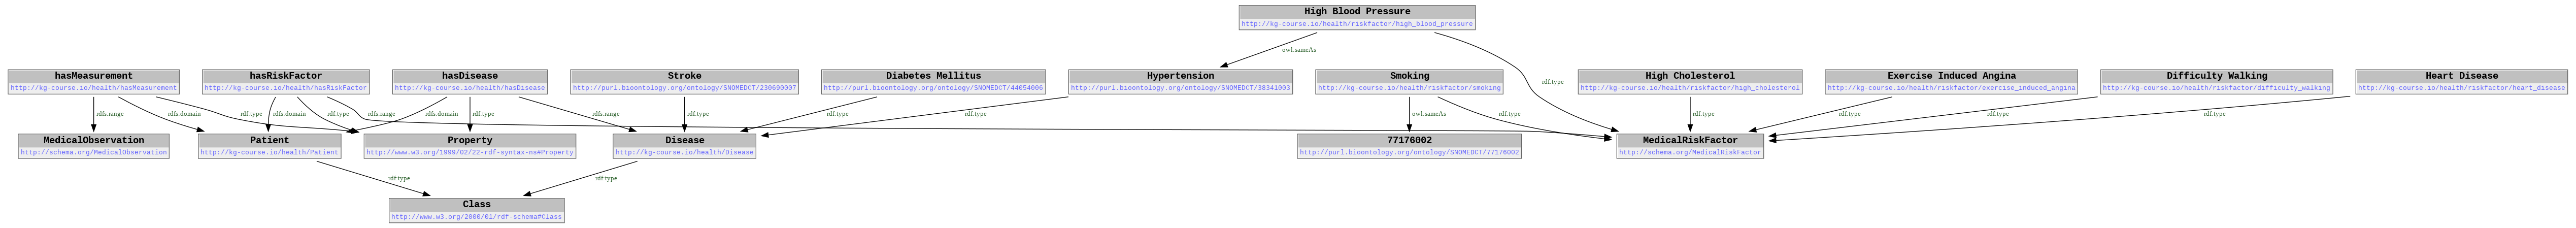

In [322]:
visualize(g)

Convert the Diabetes, Hypertension and Stroke datasets to RDF triples:

In [323]:
# DIABETES --> RDF
for idx, row in df_diabetes.iterrows():
    patient_uri = URIRef(BASE[f"patient/{idx}"])
    g.add((patient_uri, RDF.type, BASE.Patient))

    # DIABETES
    g.add((patient_uri, BASE.hasDisease, diabetes))

    # risk factors
    if row["HeartDiseaseorAttack"] == 1:
        g.add((patient_uri, BASE.hasRiskFactor, BASE["riskfactor/heart_disease"]))
    if row["DiffWalk"] == 1:
        g.add((patient_uri, BASE.hasRiskFactor, BASE["riskfactor/difficulty_walking"]))
    if row["HighBP"] == 1:
        g.add((patient_uri, BASE.hasRiskFactor, BASE["riskfactor/high_blood_pressure"]))
    if row["HighChol"] == 1:
        g.add((patient_uri, BASE.hasRiskFactor, BASE["riskfactor/high_cholesterol"]))

    # metadata
    if pd.notna(row.get("Age")):
        add_measurement(patient_uri, "Age", row["Age"], idx)
    if pd.notna(row.get("PhysHlth")):
        add_measurement(patient_uri, "PhysicalHealth", row["PhysHlth"], idx)
    if pd.notna(row.get("GenHlth")):
        add_measurement(patient_uri, "GeneralHealth", row["GenHlth"], idx)


In [324]:
# HYPERTENSION --> RDF
global_patient_counter = len(list(g.subjects(RDF.type, BASE.Patient)))
for idx, row in df_hypertension.iterrows():
    patient_uri = URIRef(BASE[f"patient/{global_patient_counter}"])
    g.add((patient_uri, RDF.type, BASE.Patient))
    g.add((patient_uri, BASE.hasDisease, hypertension))

    # Risk factor
    if row.get("exang") == 1:
        g.add((patient_uri, BASE.hasRiskFactor, BASE["riskfactor/exercise_induced_angina"]))

    # Metadata
    if pd.notna(row.get("cp")):
        add_measurement(patient_uri, "ChestPainType", row["cp"], global_patient_counter)
    if pd.notna(row.get("thalach")):
        add_measurement(patient_uri, "MaxHeartRate", row["thalach"], global_patient_counter)
    if pd.notna(row.get("slope")):
        add_measurement(patient_uri, "Slope", row["slope"], global_patient_counter)
    if pd.notna(row.get("restecg")):
        add_measurement(patient_uri, "RestingECG", row["restecg"], global_patient_counter)
    if pd.notna(row.get("oldpeak")):
        add_measurement(patient_uri, "ST_Depression", row["oldpeak"], global_patient_counter)
    if pd.notna(row.get("thal")):
        add_measurement(patient_uri, "ThalassemiaType", row["thal"], global_patient_counter)
    global_patient_counter += 1

In [304]:
# STROKE --> RDF
global_patient_counter = len(list(g.subjects(RDF.type, BASE.Patient)))

for idx, row in df_stroke.iterrows():
    patient_uri = URIRef(BASE[f"patient/{global_patient_counter}"])
    g.add((patient_uri, RDF.type, BASE.Patient))
    g.add((patient_uri, BASE.hasDisease, stroke))

    # Risk factors
    if row.get("smoking_status") == 1:
        g.add((patient_uri, BASE.hasRiskFactor, BASE["riskfactor/smoking"]))
    if row.get("hypertension") == 1:
        g.add((patient_uri, BASE.hasRiskFactor, BASE["riskfactor/high_blood_pressure"]))
    if row.get("heart_disease") == 1:
        g.add((patient_uri, BASE.hasRiskFactor, BASE["riskfactor/heart_disease"]))

    # Metadata
    if pd.notna(row.get("avg_glucose_level")):
        add_measurement(patient_uri, "AverageGlucoseLevel", row["avg_glucose_level"], global_patient_counter)
    if pd.notna(row.get("bmi")):
        add_measurement(patient_uri, "BMI", row["bmi"], global_patient_counter)
    if pd.notna(row.get("hypertension")):
        add_measurement(patient_uri, "HypertensionStatus", row["hypertension"], global_patient_counter)
    global_patient_counter += 1

Then, the **Unstructured Data** to enrich the KG with textual information. We process the clinical notes file and extract the symptons for each disease.

In [325]:
"""notes = []
with open("/content/drive/MyDrive/Colab Notebooks/Project_AndreaPradas/Data/clinical_notes.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            item = json.loads(line)
            text = item.get("input")
            if text:
                notes.append(text)
with open("clinical_notes.txt", "w", encoding="utf-8") as f:
    for note in notes:
        f.write(note + "\n\n")

print(f"Loaded {len(notes)} clinical notes.")
"""

'notes = []\nwith open("/content/drive/MyDrive/Colab Notebooks/Project_AndreaPradas/Data/clinical_notes.jsonl", "r", encoding="utf-8") as f:\n    for line in f:\n        line = line.strip()\n        if line:\n            item = json.loads(line)\n            text = item.get("input")\n            if text:\n                notes.append(text)\nwith open("clinical_notes.txt", "w", encoding="utf-8") as f:\n    for note in notes:\n        f.write(note + "\n\n")\n\nprint(f"Loaded {len(notes)} clinical notes.")\n'

In [326]:
"""def uri_safe(text):
  text = text.lower().strip()
  text = re.sub(r'[^a-z0-9\s]', '', text)
  text = re.sub(r'\s+', '_', text)
  return text
nlp_local = spacy.load("en_core_web_sm")
MAX_NOTES = 500
MAX_CHARS = 100
for note in notes[:MAX_NOTES]:
    doc = nlp_local(note[:MAX_CHARS])
    for chunk in doc.noun_chunks:
        symptom_name = chunk.text.strip().lower()
        if any(disease in symptom_name for disease in ["diabetes","hypertension","stroke"]):
            continue
        if len(symptom_name) > 5:
            symptom_uri = URIRef(BASE[f"symptom/{uri_safe(symptom_name)}"])
            g.add((symptom_uri, RDF.type, BASE.Symptom))
            g.add((symptom_uri, RDFS.label, Literal(symptom_name)))
            if "diabetes" in note.lower():
                g.add((diabetes, BASE.hasSymptom, symptom_uri))
            if "hypertension" in note.lower():
                g.add((hypertension, BASE.hasSymptom, symptom_uri))
            if "stroke" in note.lower():
                g.add((stroke, BASE.hasSymptom, symptom_uri))
"""


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_84442/3568703477.py:3: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub(r'[^a-z0-9\s]', '', text)


'def uri_safe(text):\n  text = text.lower().strip()\n  text = re.sub(r\'[^a-z0-9\\s]\', \'\', text)\n  text = re.sub(r\'\\s+\', \'_\', text)\n  return text\nnlp_local = spacy.load("en_core_web_sm")\nMAX_NOTES = 500\nMAX_CHARS = 100\nfor note in notes[:MAX_NOTES]:\n    doc = nlp_local(note[:MAX_CHARS])\n    for chunk in doc.noun_chunks:\n        symptom_name = chunk.text.strip().lower()\n        if any(disease in symptom_name for disease in ["diabetes","hypertension","stroke"]):\n            continue\n        if len(symptom_name) > 5:\n            symptom_uri = URIRef(BASE[f"symptom/{uri_safe(symptom_name)}"])\n            g.add((symptom_uri, RDF.type, BASE.Symptom))\n            g.add((symptom_uri, RDFS.label, Literal(symptom_name)))\n            if "diabetes" in note.lower():\n                g.add((diabetes, BASE.hasSymptom, symptom_uri))\n            if "hypertension" in note.lower():\n                g.add((hypertension, BASE.hasSymptom, symptom_uri))\n            if "stroke" in no

In [327]:
g.serialize("/content/drive/MyDrive/Project_AndreaPradas/Outputs/chronic_diseases_KG.ttl", format="turtle")
print(g.serialize(format='turtle'))

Output hidden; open in https://colab.research.google.com to view.

## 8. Graph Visualization

In [328]:
def visualize_small_graph(g, limit=2):
    patient_uris = [p for p in g.subjects(RDF.type, BASE.Patient)]
    patient_uris = random.sample(patient_uris, min(limit, len(patient_uris)))

    nx_graph = nx.Graph()
    node_types = {}
    patient_labels = {}

    for patient in patient_uris:
        # Etiqueta paciente
        patient_label = str(patient).split('/')[-1]
        patient_label = f"Patient{patient_label.split('patient')[-1]}"
        patient_labels[patient] = patient_label
        nx_graph.add_node(patient)
        node_types[patient] = 'patient'

        # Procesar relaciones principales
        for p, o in g.predicate_objects(patient):
            if p == RDF.type:
                continue

            # HasMeasurement: nombre + valor
            if p == BASE.hasMeasurement:
                meas_name = g.value(o, SDO.name)
                meas_value = g.value(o, SDO.value)
                label_node = f"{meas_name}: {meas_value}"
                nx_graph.add_node(o, label=label_node)
                node_types[o] = 'measurement'
                nx_graph.add_edge(patient, o, label="hasMeasurement")

            # HasDisease
            elif p == BASE.hasDisease:
                disease_label = g.value(o, RDFS.label)
                label_node = disease_label if disease_label else str(o)
                nx_graph.add_node(o, label=label_node)
                node_types[o] = 'disease'
                nx_graph.add_edge(patient, o, label="hasDisease")

            # HasRiskFactor
            elif p == BASE.hasRiskFactor:
                rf_label = g.value(o, RDFS.label)
                label_node = rf_label if rf_label else str(o)
                nx_graph.add_node(o, label=label_node)
                node_types[o] = 'riskfactor'
                nx_graph.add_edge(patient, o, label="hasRiskFactor")

            else:
                # Otros nodos literales
                nx_graph.add_node(o)
                node_types[o] = 'literal'
                nx_graph.add_edge(patient, o, label=str(p).split('/')[-1])

    # Colores por tipo de nodo
    color_map = {
        'patient': 'skyblue',
        'disease': 'red',
        'riskfactor': 'purple',
        'measurement': 'grey',
        'literal': 'orange'
    }
    node_colors = [color_map.get(node_types.get(n, 'literal')) for n in nx_graph.nodes()]

    # Etiquetas
    labels = {}
    for n in nx_graph.nodes():
        labels[n] = nx_graph.nodes[n].get('label', str(n).split('/')[-1])

    # Etiquetas de edges
    edge_labels = {(u, v): d['label'] for u, v, d in nx_graph.edges(data=True)}

    # Layout
    pos = nx.spring_layout(nx_graph, k=0.8, seed=42)
    nx.draw(nx_graph, pos, with_labels=True, labels=labels, node_size=1500, node_color=node_colors, font_size=8, font_weight='bold')
    nx.draw_networkx_edge_labels(nx_graph, pos, edge_labels=edge_labels, font_color='black', font_size=7)
    plt.title(f"Subgraph with {len(patient_uris)} patients")
    plt.show()

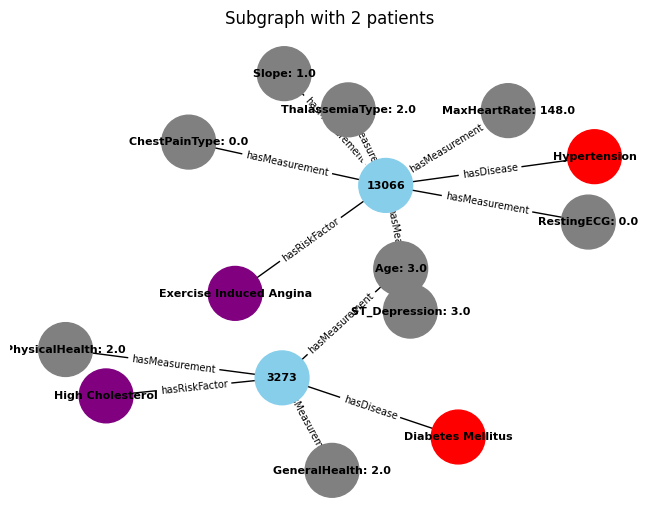

In [305]:
visualize_small_graph(g, 2)

In [329]:
mdg = rdflib_to_networkx_multidigraph(g)
dg = rdflib_to_networkx_digraph(g)
print(mdg.number_of_nodes()) # 150425 NODES
print(mdg.number_of_edges()) # 563183 EDGES

110126
412709


In [ ]:
#Save the graph

## 9. Graph Queries with SPARQL

### Quality Assessment

**Completeness**
   - **Entity count:** Verify that all patients, diseases, and risk factors are represented.
   - **Relationship coverage:** Ensure that each patient entity has associated health indicators, diagnosed diseases, and risk factors where applicable.
   - **Missing relationships:** Identify entities that lack expected relationships, e.g., patients without any disease assignment.

**Correctness**
   - **Datatype verification:** Check that numerical properties such as age or BMI are correctly typed.
   - **Unique identifiers:** Confirm that each patient entity has a unique URI.
   - **Valid relationships:** Ensure that relationships conform to the expected domain and range, e.g., `diagnosedWith` links a patient to a disease.

**Consistency**
   - **Enumerated values:** Check that categorical properties (e.g., gender, smoker status) are within expected sets.
   - **Property constraints:** Validate constraints such as non-negative values for age or BMI.

**Coherence**
   - **Orphan nodes:** Detect any entities without incoming or outgoing relationships.
   - **Transitive consistency:** Confirm that subclass and hierarchical relationships (e.g., Disease → Diabetes) are logically consistent.
   - **Cyclic relationships:** Identify any cycles in relationships where none should exist.


In [330]:
def run_sparql_query(graph, query_path):
    try:
        with open(query_path, 'r') as file:
            query = file.read()
    except Exception as _e:
        print(f"No file for {query_path}")
        return
    results = graph.query(query)
    # Display the SPARQL query
    formatted_query = highlight(query, SparqlLexer(), HtmlFormatter(style='solarized-dark', full=True, nobackground=True))
    display(HTML(formatted_query))
    # Convert results to a Pandas DataFrame
    res_list = []
    for row in results:
        res_list.append([str(item) for item in row])
    df = pd.DataFrame(res_list, columns=[str(var) for var in results.vars]) if len(res_list) > 0 else pd.DataFrame()
    # Display the DataFrame as a table in Jupyter Notebook
    display(HTML(df.to_html()))

In [351]:
# Completeness
# Count entities per classes
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/completeness_1.rq')

,class,count
0,http://kg-course.io/health/Disease,3
1,http://schema.org/MedicalRiskFactor,6
2,http://kg-course.io/health/Patient,19990
3,http://schema.org/MedicalObservation,89940


In [352]:
# Count relations per property
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/completeness_2.rq')

,property,count
0,http://kg-course.io/health/hasMeasurement,89940
1,http://kg-course.io/health/hasDisease,19990
2,http://kg-course.io/health/hasRiskFactor,12936


In [353]:
# Count relationships per property
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/completeness_3.rq')

,patient
0,http://kg-course.io/health/patient/2
1,http://kg-course.io/health/patient/4
2,http://kg-course.io/health/patient/5
3,http://kg-course.io/health/patient/7
4,http://kg-course.io/health/patient/8
5,http://kg-course.io/health/patient/9
6,http://kg-course.io/health/patient/11
7,http://kg-course.io/health/patient/15
8,http://kg-course.io/health/patient/16
9,http://kg-course.io/health/patient/17


In [354]:
# Identify patients without assigned measurements
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/completeness_4.rq')

""


In [ ]:
# Identify patients without assigned diseases

In [359]:
# Identify patients without risk factors
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/completeness_5.rq')

,property,count
0,http://kg-course.io/health/hasMeasurement,89940
1,http://kg-course.io/health/hasDisease,19990
2,http://kg-course.io/health/hasRiskFactor,12936


In [355]:
# Correctness
# Correct relations
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/correctness_1.rq')

Output hidden; open in https://colab.research.google.com to view.

In [356]:
# Datatypes
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/correctness_2.rq')

""


In [357]:
# unique id
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/correctness_3.rq')

""


In [358]:
# Consistency
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/consistency_1.rq')

""


In [360]:
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/consistency_2.rq')

ParseException: Expected SelectQuery, found 'FILTER'  (at char 110), (line:6, col:3)

In [361]:
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/consistency_3.rq')

ParseException: Expected SelectQuery, found 'FILTER'  (at char 110), (line:6, col:3)

In [362]:
# Coherence
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/coherence_1.rq')

""


In [363]:
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/coherence_2.rq')

""


In [364]:
run_sparql_query(g, '/content/drive/MyDrive/Project_AndreaPradas/Queries/coherence_3.rq')

""


PREDICTION

In [341]:
# Prevalence of diseases
q = """
PREFIX base: <http://kg-course.io/health/>

SELECT ?disease (COUNT(?p) AS ?numPatients)
WHERE {
    ?p base:diagnosedWith ?disease .
}
GROUP BY ?disease
ORDER BY DESC(?numPatients)
"""
q = prepareQuery(q)
result = g.query(q)

pd.DataFrame(result.bindings)

""
0


In [342]:
# Most common risk factors
q = """
PREFIX base: <http://kg-course.io/health/>

SELECT ?risk (COUNT(?p) AS ?numPatients)
WHERE {
    ?p base:hasRiskFactor ?risk .
}
GROUP BY ?risk
ORDER BY DESC(?numPatients)
"""
q = prepareQuery(q)
result = g.query(q)

pd.DataFrame(result.bindings)

,numPatients,risk
0,3784,http://kg-course.io/health/riskfactor/high_blo...
1,3783,http://kg-course.io/health/riskfactor/high_cho...
2,3271,http://kg-course.io/health/riskfactor/exercise...
3,1400,http://kg-course.io/health/riskfactor/difficul...
4,698,http://kg-course.io/health/riskfactor/heart_di...


In [343]:
# Risk factor associated with STROKE
q = """
PREFIX base: <http://kg-course.io/health/>

SELECT ?risk (COUNT(?p) AS ?numPatients)
WHERE {
    ?p base:diagnosedWith base:Stroke .
    ?p base:hasRiskFactor ?risk .
}
GROUP BY ?risk
ORDER BY DESC(?numPatients)
"""
q = prepareQuery(q)
result = g.query(q)

pd.DataFrame(result.bindings)

""
0


In [344]:
# Comorbidity analysis
q = """
PREFIX base: <http://kg-course.io/health/>

SELECT ?p (COUNT(?d) AS ?numDiseases)
WHERE {
    ?p base:diagnosedWith ?d .
}
GROUP BY ?p
HAVING (COUNT(?d) > 1)
ORDER BY DESC(?numDiseases)
LIMIT 20
"""

q = prepareQuery(q)
result = g.query(q)

pd.DataFrame(result.bindings)

""


In [345]:
# Stroke patients with smoking risk
q = """
PREFIX base: <http://kg-course.io/health/>

SELECT (COUNT(?p) AS ?numPatients)
WHERE {
    ?p base:diagnosedWith base:Stroke .
    ?p base:hasRiskFactor base:Smoking .
}
"""
q = prepareQuery(q)
result = g.query(q)

pd.DataFrame(result.bindings)

,numPatients
0,0


In [346]:
# Avg of BMI of stroke patients
q = """
PREFIX base: <http://kg-course.io/health/>

SELECT (AVG(?bmi) AS ?avgBMI)
WHERE {
    ?p base:diagnosedWith base:Stroke .
    ?p base:bmi ?bmi .
}
"""
q = prepareQuery(q)
result = g.query(q)

pd.DataFrame(result.bindings)

,avgBMI
0,0


In [347]:
# Patients with highest number of risk factors

q = """
PREFIX base: <http://kg-course.io/health/>

SELECT ?p (COUNT(?risk) AS ?numRisks)
WHERE {
    ?p base:hasRiskFactor ?risk .
}
GROUP BY ?p
ORDER BY DESC(?numRisks)
LIMIT 20
"""

q = prepareQuery(q)
result = g.query(q)

pd.DataFrame(result.bindings)

,numRisks,p
0,4,http://kg-course.io/health/patient/87
1,4,http://kg-course.io/health/patient/92
2,4,http://kg-course.io/health/patient/94
3,4,http://kg-course.io/health/patient/103
4,4,http://kg-course.io/health/patient/191
5,4,http://kg-course.io/health/patient/286
6,4,http://kg-course.io/health/patient/341
7,4,http://kg-course.io/health/patient/361
8,4,http://kg-course.io/health/patient/385
9,4,http://kg-course.io/health/patient/679


## 10. Key Findings
